# 📧 Email Spam Detection Using Machine Learning

### Oasis Infobyte — Data Science Internship

### Task 4: Email Spam Detection

**Author:** Himanshu Chavda  
**Track:** Data Science  
**Internship:** Oasis Infobyte SIP  
**Project Type:** Natural Language Processing (NLP) — Binary Classification

---

## 📌 Project Overview

Email and SMS spam messages have become one of the most common forms of digital communication abuse. These unwanted messages often contain advertisements, phishing attempts, fraudulent offers, malicious links, or misleading information.

This project develops an end-to-end Natural Language Processing (NLP) based machine learning system capable of automatically classifying incoming SMS messages into one of two categories:

- **Ham** — Legitimate (non-spam) messages
- **Spam** — Unwanted or fraudulent promotional messages

The complete project follows a standard machine learning workflow including data preprocessing, exploratory data analysis, text cleaning, feature engineering using TF-IDF, model training, evaluation, comparison, and interpretation.

---

## 🎯 Target Variable

**Label**

The target variable contains two classes:

- **Ham**
- **Spam**

---

## 💡 Business Objective

Manually identifying spam messages is time-consuming and unreliable when processing thousands or millions of messages every day.

An automated spam detection system helps organizations by:

- Filtering unwanted messages automatically
- Improving user experience
- Preventing phishing attacks
- Reducing fraud and malicious communication
- Increasing email security
- Supporting intelligent messaging systems

---

## 🧠 Machine Learning Approach

This project follows a complete NLP machine learning pipeline:

**Data Understanding → Data Cleaning → Exploratory Data Analysis → Text Preprocessing → TF-IDF Feature Extraction → Train/Test Split → Model Training → Model Evaluation → Model Comparison → Conclusion**

---

## 🤖 Models

Two classification algorithms are evaluated:

1. **Multinomial Naive Bayes** — Industry-standard algorithm for text classification
2. **Logistic Regression** — Strong linear classification algorithm frequently used in NLP

---

## 📊 Evaluation Metrics

The models are evaluated using:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**
- **Confusion Matrix**
- **Classification Report**

The best-performing model is selected based on its overall classification performance on unseen test data.

# Problem Statement

Electronic communication platforms receive millions of messages every day. A significant portion of these messages consists of spam content such as advertisements, phishing attempts, lottery scams, fake promotions, and malicious links.

Traditional manual filtering is inefficient and prone to human error.

Therefore, this project aims to develop a Natural Language Processing (NLP) based supervised machine learning model capable of automatically classifying SMS messages as either Spam or Ham.

---

## Problem Type

**Supervised Learning → Binary Classification**

---

## Input

Raw SMS message text.

---

## Output

Predicted message category:

- Ham
- Spam

---

## Success Criteria

The models will be compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

The best-performing model will be selected based on its overall classification performance on unseen test data.

## 1. Import Required Libraries

The following libraries are used for different stages of the project.

### Data Handling
- `pandas` — data loading and manipulation
- `numpy` — numerical operations

### Visualization
- `matplotlib` — data visualization
- `seaborn` — statistical visualization

### Natural Language Processing
- `re` — regular expressions for text cleaning
- `string` — punctuation handling
- `nltk` — natural language processing utilities

### Machine Learning
- `scikit-learn` — preprocessing, model training, and evaluation

### Visualization Enhancement
- `wordcloud` — visualization of frequently occurring words

The libraries are imported at the beginning so the complete notebook
has a clear and reproducible structure.

In [970]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Text preprocessing
import re
import string
import nltk

# NLP utilities
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Classification models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# WordCloud
from wordcloud import WordCloud

print("✅ All required libraries imported successfully.")

✅ All required libraries imported successfully.


## 2. Download NLTK Resources

NLTK provides useful natural language processing resources.

For this project, the `stopwords` dataset is required because we will
remove common English words that generally provide limited classification
information.

Examples of common stopwords include:

- the
- is
- a
- an
- and
- to
- of

Removing these words helps reduce unnecessary text features before
converting messages into numerical representations.

In [971]:
# ============================================================
# DOWNLOAD NLTK STOPWORDS
# ============================================================

nltk.download("stopwords")

print("✅ NLTK stopwords resource is ready.")

✅ NLTK stopwords resource is ready.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 3. Load the Dataset

The dataset contains SMS messages classified into two categories:

- **ham** — legitimate message
- **spam** — spam message

The dataset is stored inside the `data` folder.

Because this notebook is inside the `notebook` folder, the relative path is:

`../data/spam.csv`

We will load the dataset using pandas and inspect the first few records.

In [972]:
# ============================================================
# LOAD DATASET
# ============================================================

DATA_PATH = "../data/spam.csv"

df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully.")
print(f"📊 Dataset shape: {df.shape}")

✅ Dataset loaded successfully.
📊 Dataset shape: (5158, 2)


In [973]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 4. Dataset Structure

Before performing analysis, we need to verify the column names.

The expected columns are:

- `label` — target variable containing `ham` or `spam`
- `message` — original SMS text

The `label` column will later be used as the target variable,
while the `message` column will be processed as the input text.

In [974]:
# ============================================================
# CHECK COLUMN NAMES
# ============================================================

print("📌 Dataset columns:")
print(df.columns.tolist())

print("\n✅ Column verification completed.")

📌 Dataset columns:
['label', 'message']

✅ Column verification completed.


## 5. Dataset Dimensions

The shape of a dataset tells us:

- Number of rows
- Number of columns

Each row represents one SMS message.

Each column represents one variable.

In [975]:
# ============================================================
# CHECK DATASET SHAPE
# ============================================================

rows, columns = df.shape

print(f"📌 Number of messages : {rows}")
print(f"📌 Number of columns  : {columns}")

print("✅ Dataset dimension check completed.")

📌 Number of messages : 5158
📌 Number of columns  : 2
✅ Dataset dimension check completed.


## 6. Dataset Information

The `info()` method provides important structural information about
the dataset, including:

- Column names
- Number of non-null values
- Data types
- Memory usage

This helps us identify potential data quality problems before
starting the preprocessing stage.

In [976]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("📋 Dataset Information:\n")

df.info()

print("\n✅ Dataset information check completed.")

📋 Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5158 entries, 0 to 5157
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5158 non-null   object
 1   message  5158 non-null   object
dtypes: object(2)
memory usage: 80.7+ KB

✅ Dataset information check completed.


## 7. Descriptive Statistics

Descriptive statistics provide a high-level summary of the dataset.

For this text classification dataset, the most useful information at
this stage includes the number of messages and the distribution of
the target classes.

We will perform more detailed class analysis in the next section.

In [977]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print("📊 Descriptive Statistics:\n")

display(df.describe(include="all"))

print("\n✅ Descriptive statistics generated successfully.")

📊 Descriptive Statistics:



,label,message
count,5158,5158
unique,2,5158
top,ham,"Go until jurong point, crazy.. Available only ..."
freq,4516,1



✅ Descriptive statistics generated successfully.


## 8. Missing Value Analysis

Missing values can cause problems during machine learning.

We will check every column to determine whether any records contain
missing values.

Our two important columns are:

- `label`
- `message`

If missing values exist, they must be handled before model training.

In [978]:
# ============================================================
# CHECK MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()

print("🔍 Missing values by column:\n")
print(missing_values)

total_missing = missing_values.sum()

print(f"\n📌 Total missing values: {total_missing}")

if total_missing == 0:
    print("✅ No missing values found in the dataset.")
else:
    print("⚠️ Missing values detected. They will need to be handled.")

🔍 Missing values by column:

label      0
message    0
dtype: int64

📌 Total missing values: 0
✅ No missing values found in the dataset.


## 9. Duplicate Record Analysis

Duplicate messages can cause data leakage and may give the machine
learning model an unrealistic advantage.

Therefore, we will:

1. Count duplicate records.
2. Remove duplicate records if they exist.
3. Check the final dataset size.

In [979]:
# ============================================================
# CHECK DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()

print(f"🔍 Duplicate records found: {duplicate_count}")

🔍 Duplicate records found: 0


In [980]:
# ============================================================
# REMOVE DUPLICATE RECORDS
# ============================================================

before_duplicates = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after_duplicates = len(df)

removed_duplicates = before_duplicates - after_duplicates

print(f"📌 Records before removing duplicates: {before_duplicates}")
print(f"📌 Records after removing duplicates : {after_duplicates}")
print(f"🗑️ Duplicate records removed        : {removed_duplicates}")

print("\n✅ Duplicate handling completed.")

📌 Records before removing duplicates: 5158
📌 Records after removing duplicates : 5158
🗑️ Duplicate records removed        : 0

✅ Duplicate handling completed.


## 10. Dataset After Duplicate Removal

After removing duplicate records, we verify the final dataset shape.

This confirms that the dataset is ready for exploratory analysis.

In [981]:
# ============================================================
# FINAL DATASET SHAPE AFTER BASIC CLEANING
# ============================================================

print("📊 Final dataset shape:", df.shape)

print("\n📋 Final columns:")
print(df.columns.tolist())

print("\n✅ Basic dataset cleaning completed successfully.")

📊 Final dataset shape: (5158, 2)

📋 Final columns:
['label', 'message']

✅ Basic dataset cleaning completed successfully.


## 11. Class Distribution Analysis

The target variable contains two classes:

- **Ham** — legitimate messages
- **Spam** — unwanted messages

Understanding the class distribution is important because spam datasets
are often imbalanced, meaning that one class may contain significantly
more examples than the other.

We will calculate:

1. Number of Ham messages
2. Number of Spam messages
3. Percentage of Ham messages
4. Percentage of Spam messages

In [982]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

class_counts = df["label"].value_counts()

print("📊 Message Class Distribution:\n")

for label, count in class_counts.items():
    print(f"{label.upper():<6} : {count}")

print("\n✅ Class distribution calculated successfully.")

📊 Message Class Distribution:

HAM    : 4516
SPAM   : 642

✅ Class distribution calculated successfully.


In [983]:
# ============================================================
# CLASS DISTRIBUTION PERCENTAGE
# ============================================================

class_percentages = df["label"].value_counts(normalize=True) * 100

print("📊 Class Distribution Percentage:\n")

for label, percentage in class_percentages.items():
    print(f"{label.upper():<6} : {percentage:.2f}%")

print("\n✅ Class percentages calculated successfully.")

📊 Class Distribution Percentage:

HAM    : 87.55%
SPAM   : 12.45%

✅ Class percentages calculated successfully.


## 12. Class Distribution Summary

The following table provides a concise overview of the number and
percentage of messages belonging to each class.

In [984]:
# ============================================================
# CLASS DISTRIBUTION SUMMARY TABLE
# ============================================================

class_summary = pd.DataFrame({
    "Class": class_counts.index,
    "Message Count": class_counts.values,
    "Percentage": class_percentages.values
})

class_summary["Percentage"] = class_summary["Percentage"].round(2)

display(class_summary)

print("✅ Class distribution summary table created.")

,Class,Message Count,Percentage
0,ham,4516,87.55
1,spam,642,12.45


✅ Class distribution summary table created.


# Visualization Theme

A consistent dark visualization theme is applied throughout the spam
detection analysis to create a clean, professional, and portfolio-ready
presentation.

The visualization design uses semantic colors to distinguish between
legitimate messages (HAM) and unwanted messages (SPAM).

The theme will be used for:

- Class distribution charts
- Spam vs. ham comparison
- Confusion matrices
- WordCloud visualizations
- Model evaluation charts
- TF-IDF and text analysis visualizations

Using a consistent visual identity improves readability and makes the
machine learning results easier to interpret.

In [985]:
# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------

IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Seaborn Theme
# ------------------------------------------------------------

sns.set_theme(
    style="darkgrid",
    context="notebook"
)

# ------------------------------------------------------------
# Matplotlib Configuration
# ------------------------------------------------------------

plt.rcParams.update({
    # Figure
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    # Background
    "figure.facecolor": "#0F172A",
    "axes.facecolor": "#111827",

    # Text
    "text.color": "#F8FAFC",
    "axes.labelcolor": "#E2E8F0",
    "axes.titlecolor": "#F8FAFC",

    # Titles
    "axes.titleweight": "bold",
    "axes.titlesize": 18,

    # Labels
    "axes.labelsize": 12,

    # Ticks
    "xtick.color": "#CBD5E1",
    "ytick.color": "#CBD5E1",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Axes
    "axes.edgecolor": "#334155",

    # Grid
    "grid.color": "#334155",
    "grid.alpha": 0.30,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,

    # Legend
    "legend.fontsize": 10,

    # Saving
    "savefig.facecolor": "#0F172A",
    "savefig.edgecolor": "#0F172A"
})

print("✅ Spam detection visualization environment configured successfully.")
print(f"📁 Chart output directory: {IMAGES_DIR.resolve()}")

✅ Spam detection visualization environment configured successfully.
📁 Chart output directory: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\images


In [986]:
# ============================================================
# PROFESSIONAL NLP / SPAM DETECTION COLOR PALETTE
# ============================================================

SPAM_COLORS = {
    # --------------------------------------------------------
    # Primary visualization colors
    # --------------------------------------------------------
    "primary": "#38BDF8",
    "secondary": "#8B5CF6",

    # --------------------------------------------------------
    # Classification colors
    # --------------------------------------------------------
    "ham": "#10B981",
    "spam": "#EF4444",

    # --------------------------------------------------------
    # Model colors
    # --------------------------------------------------------
    "naive_bayes": "#38BDF8",
    "logistic_regression": "#8B5CF6",

    # --------------------------------------------------------
    # Evaluation colors
    # --------------------------------------------------------
    "correct": "#10B981",
    "incorrect": "#EF4444",
    "warning": "#F59E0B",
    "info": "#06B6D4",

    # --------------------------------------------------------
    # Text and interface colors
    # --------------------------------------------------------
    "text": "#F8FAFC",
    "muted": "#94A3B8",

    # --------------------------------------------------------
    # Background colors
    # --------------------------------------------------------
    "background": "#0F172A",
    "axes": "#111827",

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------
    "grid": "#334155"
}

print("🎨 Professional spam detection color palette loaded successfully.")

print("\nClassification colors:")
print(f"   HAM  : {SPAM_COLORS['ham']}")
print(f"   SPAM : {SPAM_COLORS['spam']}")

print("\nModel colors:")
print(f"   Naive Bayes        : {SPAM_COLORS['naive_bayes']}")
print(f"   Logistic Regression: {SPAM_COLORS['logistic_regression']}")

🎨 Professional spam detection color palette loaded successfully.

Classification colors:
   HAM  : #10B981
   SPAM : #EF4444

Model colors:
   Naive Bayes        : #38BDF8
   Logistic Regression: #8B5CF6


In [987]:
# ============================================================
# REUSABLE SPAM DETECTION CHART FORMATTING FUNCTION
# ============================================================

def format_spam_chart(
    title,
    xlabel=None,
    ylabel=None,
    grid_axis="both"
):
    """
    Apply consistent professional formatting to Task 4 charts.

    Parameters
    ----------
    title : str
        Chart title.

    xlabel : str, optional
        X-axis label.

    ylabel : str, optional
        Y-axis label.

    grid_axis : str
        Grid direction: "both", "x", "y", or "none".
    """

    ax = plt.gca()

    # --------------------------------------------------------
    # Chart title
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        color=SPAM_COLORS["text"],
        pad=18
    )

    # --------------------------------------------------------
    # X-axis label
    # --------------------------------------------------------

    if xlabel:
        ax.set_xlabel(
            xlabel,
            fontsize=12,
            fontweight="medium",
            color=SPAM_COLORS["text"],
            labelpad=10
        )

    # --------------------------------------------------------
    # Y-axis label
    # --------------------------------------------------------

    if ylabel:
        ax.set_ylabel(
            ylabel,
            fontsize=12,
            fontweight="medium",
            color=SPAM_COLORS["text"],
            labelpad=10
        )

    # --------------------------------------------------------
    # Tick formatting
    # --------------------------------------------------------

    ax.tick_params(
        axis="both",
        colors=SPAM_COLORS["muted"],
        labelsize=10
    )

    # --------------------------------------------------------
    # Grid formatting
    # --------------------------------------------------------

    if grid_axis != "none":
        ax.grid(
            True,
            axis=grid_axis,
            color=SPAM_COLORS["grid"],
            linestyle="--",
            linewidth=0.7,
            alpha=0.30
        )
    else:
        ax.grid(False)

    # --------------------------------------------------------
    # Remove unnecessary borders
    # --------------------------------------------------------

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --------------------------------------------------------
    # Keep subtle left and bottom borders
    # --------------------------------------------------------

    ax.spines["left"].set_color(
        SPAM_COLORS["grid"]
    )

    ax.spines["bottom"].set_color(
        SPAM_COLORS["grid"]
    )

    # --------------------------------------------------------
    # Professional layout
    # --------------------------------------------------------

    plt.tight_layout()


print("📊 Reusable spam detection chart formatting function created successfully.")
print("✅ Visualization environment is ready for Task 4.")

📊 Reusable spam detection chart formatting function created successfully.
✅ Visualization environment is ready for Task 4.


## 13. Class Distribution — Ham vs. Spam Messages

This visualization shows the distribution of legitimate (HAM) and spam
messages in the dataset.

Understanding class distribution is an important first step in spam
classification because an imbalanced dataset can influence model
performance and evaluation metrics.

The chart uses semantic colors:
- HAM represents legitimate messages.
- SPAM represents unwanted or suspicious messages.

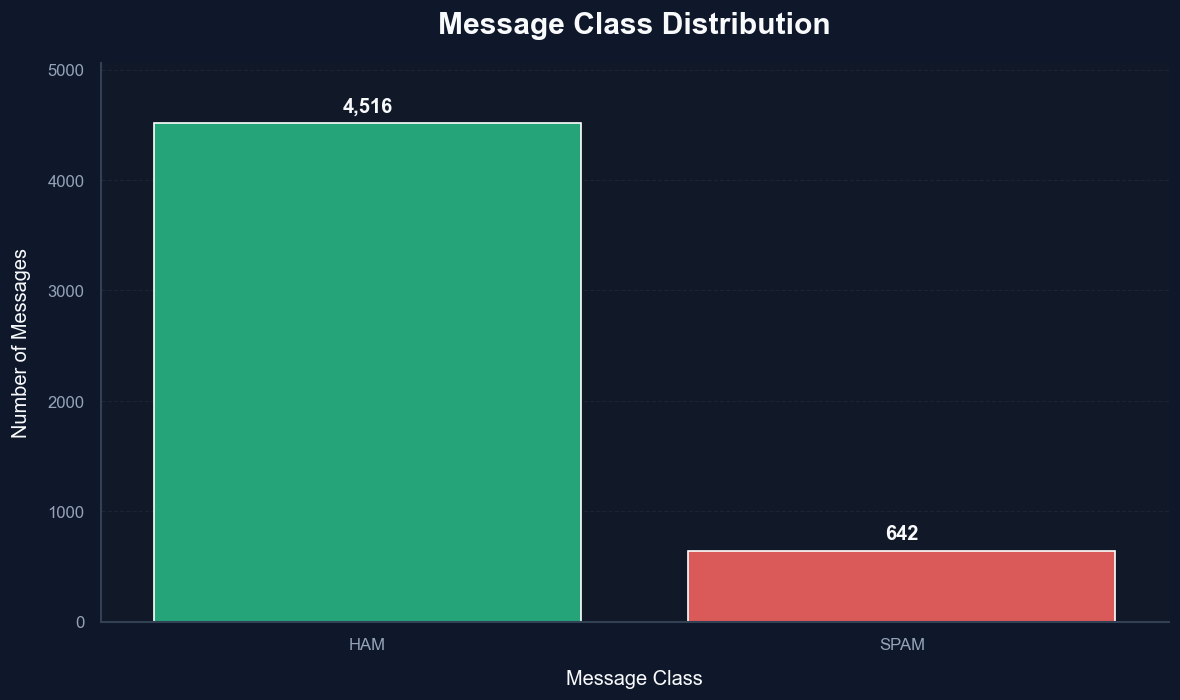

✅ Class distribution bar chart generated successfully.
📁 Chart saved to: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\images\class_distribution.png

Class Counts:
label
ham     4516
spam     642
Name: count, dtype: int64


In [988]:
# ============================================================
# TASK 4 — CLASS DISTRIBUTION BAR CHART
# ============================================================

# ------------------------------------------------------------
# Calculate class counts
# ------------------------------------------------------------

class_counts = (
    df["label"]
    .value_counts()
    .reindex(["ham", "spam"])
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=class_counts.index.str.upper(),
    y=class_counts.values,
    hue=class_counts.index.str.upper(),
    palette=[
        SPAM_COLORS["ham"],
        SPAM_COLORS["spam"]
    ],
    legend=False
)

# ------------------------------------------------------------
# Add value labels
# ------------------------------------------------------------

for bar, value in zip(ax.patches, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + class_counts.max() * 0.015,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=SPAM_COLORS["text"]
    )

# ------------------------------------------------------------
# Apply professional formatting
# ------------------------------------------------------------

format_spam_chart(
    title="Message Class Distribution",
    xlabel="Message Class",
    ylabel="Number of Messages",
    grid_axis="y"
)

# ------------------------------------------------------------
# Set Y-axis margin for value labels
# ------------------------------------------------------------

plt.ylim(
    0,
    class_counts.max() * 1.12
)

# ------------------------------------------------------------
# Save chart
# ------------------------------------------------------------

chart_path = IMAGES_DIR / "class_distribution.png"

plt.savefig(
    chart_path,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("✅ Class distribution bar chart generated successfully.")
print(f"📁 Chart saved to: {chart_path.resolve()}")
print("\nClass Counts:")
print(class_counts)

### 🔎 Key Observation

The dataset contains substantially more HAM messages than SPAM messages,
indicating a class imbalance.

This imbalance should be considered when evaluating the classification
models. Accuracy alone may not fully represent model performance, so
precision, recall, and F1-score will also be used during evaluation.

## 14. Class Distribution — Ham vs Spam

The pie chart below shows the overall distribution of legitimate (HAM)
and unwanted (SPAM) messages in the dataset.

This visualization helps identify whether the dataset is balanced or
contains a class imbalance before building the classification models.

- **HAM:** Legitimate messages
- **SPAM:** Unwanted or potentially fraudulent messages

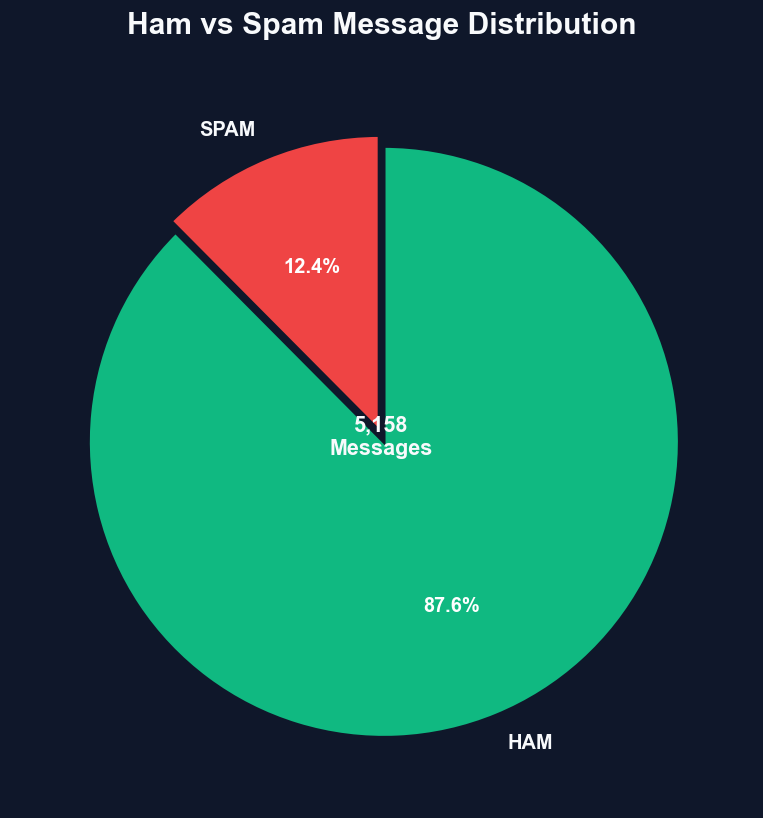

✅ Class distribution pie chart generated successfully.
📊 Total messages: 5,158
🟢 Ham messages : 4,516
🔴 Spam messages: 642
💾 Chart saved: images/01_class_distribution_pie.png


In [989]:
# ============================================================
# TASK 4 — CLASS DISTRIBUTION PIE CHART
# ============================================================

# ------------------------------------------------------------
# Calculate class distribution
# ------------------------------------------------------------

class_counts = df["label"].value_counts()

# ------------------------------------------------------------
# Map semantic colors
# ------------------------------------------------------------

pie_colors = [
    SPAM_COLORS["ham"] if label == "ham"
    else SPAM_COLORS["spam"]
    for label in class_counts.index
]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

# ------------------------------------------------------------
# Create pie chart
# ------------------------------------------------------------

wedges, texts, autotexts = ax.pie(
    class_counts.values,
    labels=class_counts.index.str.upper(),
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=pie_colors,
    explode=[0.02] * len(class_counts),
    shadow=False,
    wedgeprops={
        "edgecolor": SPAM_COLORS["background"],
        "linewidth": 2
    },
    textprops={
        "fontsize": 12,
        "fontweight": "bold",
        "color": SPAM_COLORS["text"]
    }
)

# ------------------------------------------------------------
# Format percentage labels
# ------------------------------------------------------------

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

# ------------------------------------------------------------
# Chart title
# ------------------------------------------------------------

ax.set_title(
    "Ham vs Spam Message Distribution",
    fontsize=18,
    fontweight="bold",
    color=SPAM_COLORS["text"],
    pad=20
)

# ------------------------------------------------------------
# Center text
# ------------------------------------------------------------

total_messages = class_counts.sum()

ax.text(
    0,
    0,
    f"{total_messages:,}\nMessages",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color=SPAM_COLORS["text"]
)

# ------------------------------------------------------------
# Save chart
# ------------------------------------------------------------

plt.savefig(
    IMAGES_DIR / "class_distribution_pie.png",
    bbox_inches="tight",
    facecolor=SPAM_COLORS["background"]
)

plt.show()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("✅ Class distribution pie chart generated successfully.")
print(f"📊 Total messages: {total_messages:,}")
print(f"🟢 Ham messages : {class_counts.get('ham', 0):,}")
print(f"🔴 Spam messages: {class_counts.get('spam', 0):,}")
print("💾 Chart saved: images/01_class_distribution_pie.png")

### 🔎 Key Observation

The dataset contains a substantially higher proportion of HAM messages
than SPAM messages, indicating a class imbalance.

Therefore, model evaluation should not rely on accuracy alone.
Precision, recall, F1-score, and the confusion matrix should also be
considered to properly evaluate spam detection performance.

## 15. SMS Message Class Distribution

The class distribution visualization shows the number of legitimate (HAM)
and unwanted (SPAM) messages in the dataset.

Understanding the target-class distribution is important before model
training because class imbalance can influence machine learning
performance and evaluation metrics.

HAM messages represent legitimate communication, while SPAM messages
represent unwanted or potentially fraudulent messages.

C:\Users\USER\AppData\Local\Temp\ipykernel_1940\2221995265.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


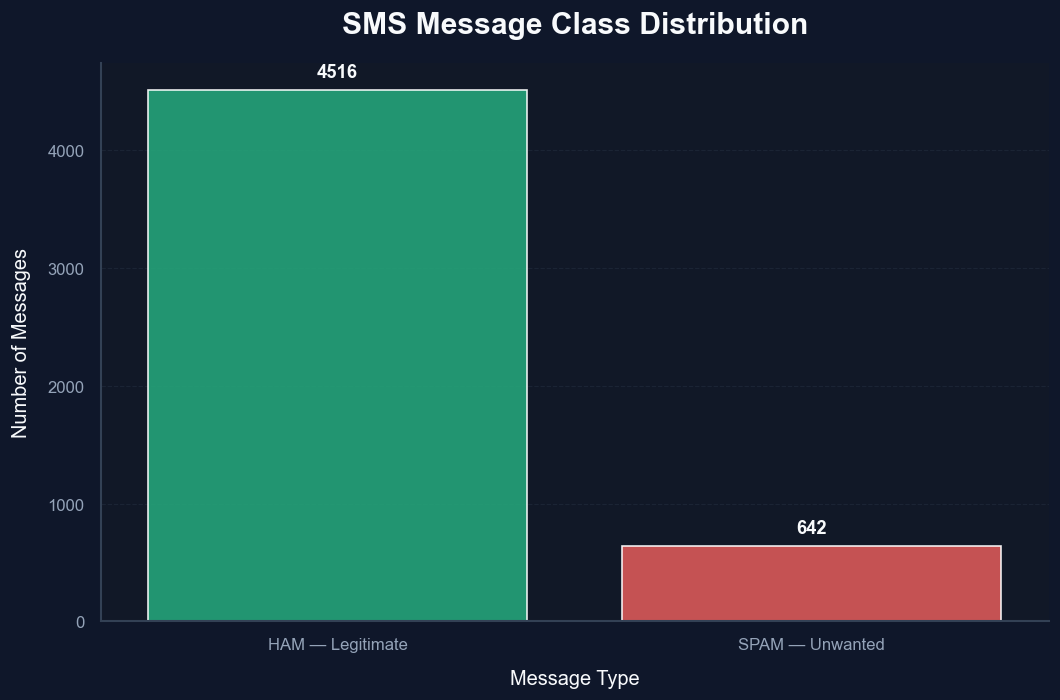

✅ Class distribution chart generated successfully.
📁 Chart saved to: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\images\sms_message_class_distribution.png
📊 Total messages visualized: 5,158


In [990]:
# ============================================================
# TASK 4 — SMS MESSAGE CLASS DISTRIBUTION
# PROFESSIONAL CLASS COUNT VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x="label",
    order=["ham", "spam"],
    hue="label",
    palette={
        "ham": SPAM_COLORS["ham"],
        "spam": SPAM_COLORS["spam"]
    },
    legend=False
)

# ------------------------------------------------------------
# Apply professional chart formatting
# ------------------------------------------------------------

format_spam_chart(
    title="SMS Message Class Distribution",
    xlabel="Message Type",
    ylabel="Number of Messages",
    grid_axis="y"
)

# ------------------------------------------------------------
# Add count labels above each bar
# ------------------------------------------------------------

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=5,
        fontsize=11,
        fontweight="bold",
        color=SPAM_COLORS["text"]
    )

# ------------------------------------------------------------
# Improve X-axis labels
# ------------------------------------------------------------

ax.set_xticklabels(
    ["HAM — Legitimate", "SPAM — Unwanted"]
)

# ------------------------------------------------------------
# Add subtle visual emphasis to bars
# ------------------------------------------------------------

for bar in ax.patches:
    bar.set_alpha(0.90)

# ------------------------------------------------------------
# Save high-resolution chart
# ------------------------------------------------------------

chart_path = IMAGES_DIR / "sms_message_class_distribution.png"

plt.savefig(
    chart_path,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("✅ Class distribution chart generated successfully.")
print(f"📁 Chart saved to: {chart_path.resolve()}")
print(f"📊 Total messages visualized: {len(df):,}")

### 🔎 Key Observation

The dataset contains a substantially larger number of HAM messages than
SPAM messages, indicating an imbalanced target distribution.

This imbalance should be considered during model evaluation, where
precision, recall, and F1-score provide more informative insights than
accuracy alone.

## 16. EDA Observation — Class Distribution

### Key Observations

- The dataset contains two classes: **Ham** and **Spam**.
- Ham messages represent the majority of the dataset.
- Spam messages represent a smaller proportion of the dataset.
- Therefore, the dataset shows a degree of **class imbalance**.

### Why does this matter?

Class imbalance should be considered when evaluating a spam detection
model. Accuracy alone may not provide a complete picture of model
performance.

For this reason, we will also evaluate:

- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics will help us understand how effectively the model
identifies spam messages.

## 17. Final Data Validation

Before moving to text preprocessing, we perform a final validation
to ensure:

- Required columns exist.
- No missing labels exist.
- No missing messages exist.
- Duplicate records have been removed.
- The target variable contains only the expected classes.

In [991]:
# ============================================================
# FINAL DATA VALIDATION
# ============================================================

required_columns = ["label", "message"]

# Check required columns
columns_available = all(
    column in df.columns for column in required_columns
)

# Check missing values
missing_total = df[required_columns].isnull().sum().sum()

# Check duplicate records
duplicate_total = df.duplicated().sum()

# Check target classes
valid_labels = set(df["label"].unique()).issubset({"ham", "spam"})

print("🔎 FINAL DATA VALIDATION")
print("=" * 50)

print(f"Required columns available : {columns_available}")
print(f"Missing values             : {missing_total}")
print(f"Duplicate records          : {duplicate_total}")
print(f"Valid target labels        : {valid_labels}")

if (
    columns_available
    and missing_total == 0
    and duplicate_total == 0
    and valid_labels
):
    print("\n🎉 Dataset validation PASSED.")
    print("✅ Dataset is ready for NLP preprocessing.")
else:
    print("\n⚠️ Dataset validation requires attention.")

🔎 FINAL DATA VALIDATION
Required columns available : True
Missing values             : 0
Duplicate records          : 0
Valid target labels        : True

🎉 Dataset validation PASSED.
✅ Dataset is ready for NLP preprocessing.


## 18. Natural Language Processing — Text Preprocessing

Machine learning algorithms cannot directly understand raw SMS text.

For example:

"Congratulations! You have WON £1,000!!!"

contains:

- Uppercase characters
- Punctuation
- Numbers
- Special characters

Therefore, the text must be transformed into a cleaner and more
consistent representation before feature extraction.

### Preprocessing Steps

The preprocessing pipeline will perform:

1. Convert text to lowercase
2. Remove URLs
3. Remove punctuation
4. Remove numbers
5. Remove extra whitespace
6. Remove stopwords
7. Apply stemming

The resulting cleaned text will be stored in a new column called
`clean_message`.

In [992]:
# ============================================================
# NLP PREPROCESSING SETUP
# ============================================================

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Initialize Porter Stemmer
stemmer = PorterStemmer()

print("✅ NLP preprocessing components initialized successfully.")
print(f"📚 Number of English stopwords loaded: {len(stop_words)}")
print("🌱 Porter Stemmer initialized successfully.")

✅ NLP preprocessing components initialized successfully.
📚 Number of English stopwords loaded: 198
🌱 Porter Stemmer initialized successfully.


## 19. Create the Text Cleaning Function

A reusable preprocessing function makes the workflow cleaner and
more maintainable.

The function will process each SMS message through the following
sequence:

**Raw Text**
→ Lowercase
→ URL Removal
→ Punctuation Removal
→ Number Removal
→ Whitespace Normalization
→ Stopword Removal
→ Stemming
→ **Clean Text**

Stemming reduces words to their root-like form.

For example:

- `playing` → `play`
- `played` → `play`
- `plays` → `play`

This can reduce the number of unique text features used by the model.

In [993]:
# ============================================================
# TEXT PREPROCESSING FUNCTION
# ============================================================

def clean_text(text):
    """
    Clean and normalize an SMS message for NLP processing.

    Steps:
    1. Convert text to lowercase
    2. Remove URLs
    3. Remove punctuation
    4. Remove numbers
    5. Normalize whitespace
    6. Remove stopwords
    7. Apply stemming
    """

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords and apply stemming
    words = text.split()

    cleaned_words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(cleaned_words)


print("✅ Text cleaning function created successfully.")

✅ Text cleaning function created successfully.


## 20. Apply Text Preprocessing

The cleaning function is now applied to every SMS message in the
dataset.

The original `message` column will be preserved so that we can compare
the original text with the cleaned version.

A new column called `clean_message` will contain the processed text.

In [994]:
# ============================================================
# APPLY TEXT PREPROCESSING
# ============================================================

df["clean_message"] = df["message"].apply(clean_text)

print("✅ Text preprocessing applied successfully.")
print(f"📊 Messages processed: {len(df):,}")
print("📝 New column created: clean_message")

✅ Text preprocessing applied successfully.
📊 Messages processed: 5,158
📝 New column created: clean_message


## 21. Compare Original and Cleaned Messages

To verify that preprocessing is working correctly, we will compare
the original SMS messages with their cleaned versions.

This allows us to visually inspect the effect of:

- Lowercasing
- Punctuation removal
- Number removal
- Stopword removal
- Stemming

In [995]:
# ============================================================
# ORIGINAL VS CLEANED TEXT
# ============================================================

comparison = df[["message", "clean_message"]].head(10)

display(comparison)

print("✅ Original and cleaned messages displayed successfully.")

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea £ p...
9,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mob...


✅ Original and cleaned messages displayed successfully.


## 22. Text Preprocessing Summary

The preprocessing stage transforms unstructured SMS text into a more
consistent representation.

### Transformations performed

| Processing Step | Purpose |
|---|---|
| Lowercase conversion | Treat uppercase and lowercase words consistently |
| URL removal | Remove web addresses that may create unnecessary features |
| Punctuation removal | Reduce irrelevant symbols |
| Number removal | Remove standalone numerical tokens |
| Stopword removal | Reduce common words with limited discriminatory value |
| Stemming | Reduce related words to a common root form |

The cleaned text will now be used for feature extraction.

## 23. TF-IDF Feature Extraction

Machine learning algorithms require numerical input, but SMS messages
are written as text.

To convert the cleaned messages into numerical features, we use
**TF-IDF (Term Frequency–Inverse Document Frequency)**.

### What is TF-IDF?

TF-IDF measures how important a word is within a document relative
to the complete collection of documents.

### Term Frequency (TF)

Measures how frequently a term appears in a particular message.

### Inverse Document Frequency (IDF)

Reduces the importance of words that appear across many messages.

### TF-IDF

The two components are combined to assign a numerical importance
score to each word.

Therefore:

- Frequently occurring words within a message can receive higher weight.
- Words appearing in almost every message receive lower weight.
- More distinctive words can receive higher importance.

This allows machine learning algorithms to work with textual data
as numerical feature vectors.

## 24. Train-Test Split

Before applying TF-IDF, the dataset is divided into training and
testing sets.

### Training Set
Used to learn patterns from the messages.

### Testing Set
Used to evaluate how well the trained models perform on previously
unseen messages.

We use an **80/20 split**:

- 80% → Training data
- 20% → Testing data

The `stratify` parameter is used to preserve the Ham/Spam class
distribution in both subsets.

In [996]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

X = df["clean_message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✅ Train-test split completed successfully.")
print(f"📚 Training samples: {len(X_train):,}")
print(f"🧪 Testing samples : {len(X_test):,}")
print(f"📊 Training size   : {len(X_train) / len(df) * 100:.1f}%")
print(f"📊 Testing size    : {len(X_test) / len(df) * 100:.1f}%")

✅ Train-test split completed successfully.
📚 Training samples: 4,126
🧪 Testing samples : 1,032
📊 Training size   : 80.0%
📊 Testing size    : 20.0%


## 25. Apply TF-IDF Vectorization

The `TfidfVectorizer` converts cleaned SMS messages into numerical
feature vectors.

Importantly, the vectorizer is **fitted only on the training data**.

The test data is transformed using the vocabulary learned from the
training data.

This prevents information leakage from the test set into the
training process.

We will also limit the feature space using `min_df` to ignore terms
that occur extremely rarely.

In [997]:
# ============================================================
# TF-IDF FEATURE EXTRACTION
# ============================================================

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    ngram_range=(1, 2)
)

# Learn vocabulary and transform training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data using training vocabulary
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("✅ TF-IDF vectorization completed successfully.")
print(f"📚 Training TF-IDF shape: {X_train_tfidf.shape}")
print(f"🧪 Testing TF-IDF shape : {X_test_tfidf.shape}")
print(f"🔤 Number of features   : {len(tfidf_vectorizer.get_feature_names_out()):,}")

✅ TF-IDF vectorization completed successfully.
📚 Training TF-IDF shape: (4126, 5000)
🧪 Testing TF-IDF shape : (1032, 5000)
🔤 Number of features   : 5,000


## 26. Inspect TF-IDF Features

The vectorizer has converted the SMS collection into a numerical
matrix.

Each row represents one SMS message.

Each column represents a text feature generated by TF-IDF.

We will inspect a small sample of the vocabulary to understand what
the model is receiving as input.

In [998]:
# ============================================================
# INSPECT TF-IDF VOCABULARY
# ============================================================

feature_names = tfidf_vectorizer.get_feature_names_out()

print("🔤 Sample TF-IDF features:")
print(feature_names[:30])

print(f"\n📊 Total TF-IDF features: {len(feature_names):,}")
print("✅ TF-IDF feature inspection completed.")

🔤 Sample TF-IDF features:
['aah' 'abi' 'abiola' 'abl' 'abl deliv' 'abl pay' 'abt' 'abt alreadi'
 'abt tht' 'abt ur' 'abta' 'abta complimentari' 'aburo' 'aburo enjoy' 'ac'
 'acc' 'accept' 'access' 'access number' 'accid' 'accid claim' 'accomod'
 'accordingli' 'account' 'account bank' 'account statement' 'ach' 'aclpm'
 'across' 'across sea']

📊 Total TF-IDF features: 5,000
✅ TF-IDF feature inspection completed.


## 27. Model 1 — Multinomial Naive Bayes

Multinomial Naive Bayes is a popular classification algorithm for
text-based problems.

It works particularly well with feature representations such as
word counts and TF-IDF.

For this project, Multinomial Naive Bayes will serve as our first
spam classification model.

The model will learn the relationship between the TF-IDF features
and the two target classes:

- Ham
- Spam

In [999]:
# ============================================================
# MODEL 1 — MULTINOMIAL NAIVE BAYES
# ============================================================

naive_bayes_model = MultinomialNB()

naive_bayes_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = naive_bayes_model.predict(X_test_tfidf)

print("✅ Multinomial Naive Bayes trained successfully.")
print(f"📊 Predictions generated: {len(y_pred_nb):,}")

✅ Multinomial Naive Bayes trained successfully.
📊 Predictions generated: 1,032


## 28. Model 2 — Logistic Regression

Logistic Regression is a widely used classification algorithm that
can perform effectively on high-dimensional text data.

It provides a useful alternative to Naive Bayes and allows us to
compare two different approaches to the same classification problem.

The model will be trained using the same TF-IDF features and the
same training/testing split to ensure a fair comparison.

In [1000]:
# ============================================================
# MODEL 2 — LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr = logistic_model.predict(X_test_tfidf)

print("✅ Logistic Regression trained successfully.")
print(f"📊 Predictions generated: {len(y_pred_lr):,}")

✅ Logistic Regression trained successfully.
📊 Predictions generated: 1,032


## 29. Model Evaluation

Two classification models have now been trained.

We will evaluate them using four important metrics:

### Accuracy
The overall percentage of correctly classified messages.

### Precision
Among messages predicted as spam, precision measures how many
were actually spam.

### Recall
Among all actual spam messages, recall measures how many were
successfully detected.

### F1-Score
The harmonic mean of precision and recall.

F1-score is particularly useful when the classes are imbalanced
because it considers both false positives and false negatives.

In [1001]:
# ============================================================
# MODEL EVALUATION METRICS
# ============================================================

# Naive Bayes metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, pos_label="spam")
nb_recall = recall_score(y_test, y_pred_nb, pos_label="spam")
nb_f1 = f1_score(y_test, y_pred_nb, pos_label="spam")

# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, pos_label="spam")
lr_recall = recall_score(y_test, y_pred_lr, pos_label="spam")
lr_f1 = f1_score(y_test, y_pred_lr, pos_label="spam")

print("📊 MODEL PERFORMANCE")
print("=" * 60)

print("\nMultinomial Naive Bayes")
print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1-Score  : {nb_f1:.4f}")

print("\nLogistic Regression")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1-Score  : {lr_f1:.4f}")

print("\n✅ Model evaluation metrics calculated successfully.") 

📊 MODEL PERFORMANCE

Multinomial Naive Bayes
Accuracy  : 0.9671
Precision : 1.0000
Recall    : 0.7344
F1-Score  : 0.8468

Logistic Regression
Accuracy  : 0.9641
Precision : 0.9691
Recall    : 0.7344
F1-Score  : 0.8356

✅ Model evaluation metrics calculated successfully.


## 30. Classification Reports

A classification report provides a detailed evaluation of each model.

It includes:

- Precision
- Recall
- F1-score
- Support

The report is generated separately for Ham and Spam classes so that
we can understand how each model performs for both categories.

In [1002]:
# ============================================================
# CLASSIFICATION REPORT — NAIVE BAYES
# ============================================================

print("📋 MULTINOMIAL NAIVE BAYES — CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Ham", "Spam"]
    )
)

print("✅ Naive Bayes classification report generated.")

📋 MULTINOMIAL NAIVE BAYES — CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       904
        Spam       1.00      0.73      0.85       128

    accuracy                           0.97      1032
   macro avg       0.98      0.87      0.91      1032
weighted avg       0.97      0.97      0.96      1032

✅ Naive Bayes classification report generated.


In [1003]:
# ============================================================
# CLASSIFICATION REPORT — LOGISTIC REGRESSION
# ============================================================

print("📋 LOGISTIC REGRESSION — CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Ham", "Spam"]
    )
)

print("✅ Logistic Regression classification report generated.")

📋 LOGISTIC REGRESSION — CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       904
        Spam       0.97      0.73      0.84       128

    accuracy                           0.96      1032
   macro avg       0.97      0.87      0.91      1032
weighted avg       0.96      0.96      0.96      1032

✅ Logistic Regression classification report generated.


## 31. Confusion Matrix — Multinomial Naive Bayes

A confusion matrix provides a detailed view of how the Multinomial
Naive Bayes classifier performs on HAM and SPAM messages.

It compares the actual message class with the class predicted by the model.

The four outcomes are:

- **True Negative (TN):** HAM correctly classified as HAM.
- **False Positive (FP):** HAM incorrectly classified as SPAM.
- **False Negative (FN):** SPAM incorrectly classified as HAM.
- **True Positive (TP):** SPAM correctly classified as SPAM.

For spam detection, the False Negative value is particularly important
because it represents spam messages that were incorrectly identified as
legitimate messages.

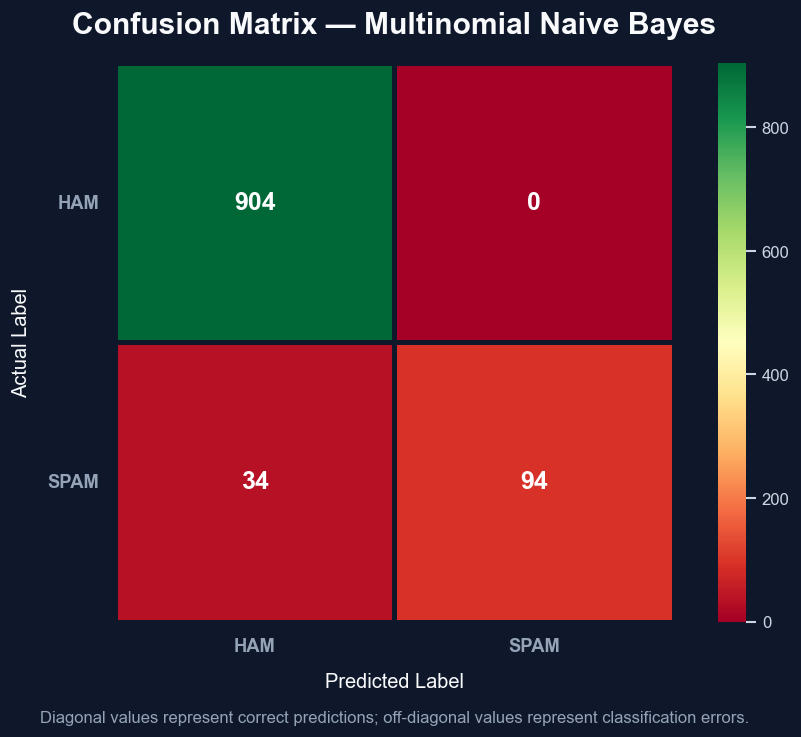

✅ Naive Bayes confusion matrix generated successfully.
📁 Saved to: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\images\confusion_matrix_naive_bayes.png

📊 Confusion Matrix Values:
   HAM  → HAM  : 904
   HAM  → SPAM : 0
   SPAM → HAM  : 34
   SPAM → SPAM : 94


In [1004]:
# ============================================================
# TASK 4 — CONFUSION MATRIX
# MULTINOMIAL NAIVE BAYES
# ============================================================

# ------------------------------------------------------------
# Calculate confusion matrix
# ------------------------------------------------------------

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=["ham", "spam"]
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

# ------------------------------------------------------------
# Draw heatmap
# ------------------------------------------------------------

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="RdYlGn",
    linewidths=2,
    linecolor=SPAM_COLORS["background"],
    square=True,
    cbar=True,
    annot_kws={
        "fontsize": 15,
        "fontweight": "bold"
    },
    xticklabels=["HAM", "SPAM"],
    yticklabels=["HAM", "SPAM"]
)

# ------------------------------------------------------------
# Apply project-wide chart formatting
# ------------------------------------------------------------

format_spam_chart(
    title="Confusion Matrix — Multinomial Naive Bayes",
    xlabel="Predicted Label",
    ylabel="Actual Label",
    grid_axis="none"
)

# ------------------------------------------------------------
# Improve tick appearance
# ------------------------------------------------------------

plt.xticks(
    rotation=0,
    fontsize=11,
    fontweight="bold"
)

plt.yticks(
    rotation=0,
    fontsize=11,
    fontweight="bold"
)

# ------------------------------------------------------------
# Add explanatory subtitle
# ------------------------------------------------------------

plt.text(
    0.5,
    -0.18,
    "Diagonal values represent correct predictions; "
    "off-diagonal values represent classification errors.",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=10,
    color=SPAM_COLORS["muted"]
)

# ------------------------------------------------------------
# Save chart
# ------------------------------------------------------------

output_path = IMAGES_DIR / "confusion_matrix_naive_bayes.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=SPAM_COLORS["background"]
)

plt.show()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("✅ Naive Bayes confusion matrix generated successfully.")
print(f"📁 Saved to: {output_path.resolve()}")

print("\n📊 Confusion Matrix Values:")
print(f"   HAM  → HAM  : {cm_nb[0, 0]}")
print(f"   HAM  → SPAM : {cm_nb[0, 1]}")
print(f"   SPAM → HAM  : {cm_nb[1, 0]}")
print(f"   SPAM → SPAM : {cm_nb[1, 1]}")

### 🔎 Key Observation

The confusion matrix shows how effectively the Multinomial Naive Bayes
model separates legitimate HAM messages from SPAM messages.

The diagonal cells represent correctly classified messages, while the
off-diagonal cells represent classification errors.

For spam detection, particular attention should be given to the
**SPAM → HAM** errors because these are spam messages that the model
failed to detect. Therefore, minimizing false negatives is important
for building a reliable spam detection system.

Confusion Matrix — Logistic Regression

A confusion matrix provides a detailed view of the Logistic Regression
classifier's predictions for HAM and SPAM messages.

It compares the actual class of each message with the class predicted
by the model.

The four outcomes are:

- **True Negative (TN):** HAM correctly classified as HAM.
- **False Positive (FP):** HAM incorrectly classified as SPAM.
- **False Negative (FN):** SPAM incorrectly classified as HAM.
- **True Positive (TP):** SPAM correctly classified as SPAM.

For spam detection, False Negatives are particularly important because
they represent actual spam messages that the model failed to detect.

The matrix is displayed using actual labels on the Y-axis and predicted
labels on the X-axis.

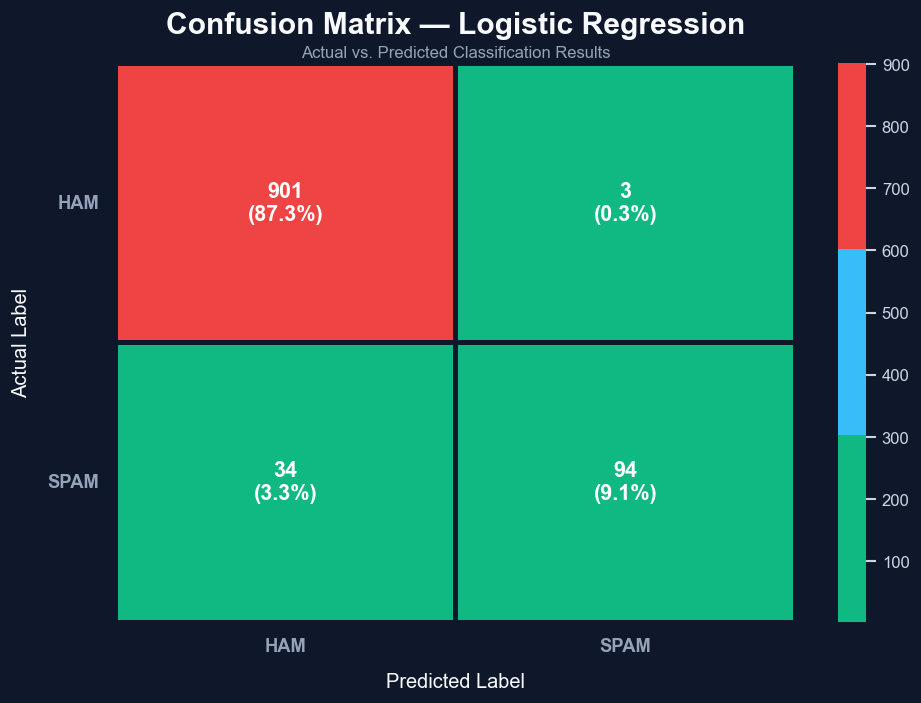

✅ Logistic Regression confusion matrix generated successfully.
True Negatives  (HAM → HAM)   : 901
False Positives (HAM → SPAM)  : 3
False Negatives (SPAM → HAM)  : 34
True Positives  (SPAM → SPAM) : 94
📊 Total predictions           : 1,032
📁 Saved to                    : ..\images\confusion_matrix_logistic_regression.png


In [1005]:
# ============================================================
# TASK 4 — CONFUSION MATRIX
# LOGISTIC REGRESSION
# ============================================================

# ------------------------------------------------------------
# Calculate confusion matrix
# ------------------------------------------------------------

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["ham", "spam"]
)

# ------------------------------------------------------------
# Calculate total predictions
# ------------------------------------------------------------

total_predictions = cm_lr.sum()

# ------------------------------------------------------------
# Convert counts into percentages
# ------------------------------------------------------------

cm_lr_percentage = (
    cm_lr / total_predictions
) * 100

# ------------------------------------------------------------
# Create professional figure
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

# ------------------------------------------------------------
# Create annotation labels
# Count + percentage
# ------------------------------------------------------------

annotations = np.empty_like(
    cm_lr,
    dtype=object
)

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        annotations[i, j] = (
            f"{cm_lr[i, j]:,}\n"
            f"({cm_lr_percentage[i, j]:.1f}%)"
        )

# ------------------------------------------------------------
# Draw heatmap
# ------------------------------------------------------------

sns.heatmap(
    cm_lr,
    annot=annotations,
    fmt="",
    cmap=sns.color_palette(
        [
            SPAM_COLORS["ham"],
            SPAM_COLORS["primary"],
            SPAM_COLORS["spam"]
        ],
        as_cmap=True
    ),
    linewidths=2,
    linecolor=SPAM_COLORS["background"],
    xticklabels=["HAM", "SPAM"],
    yticklabels=["HAM", "SPAM"],
    cbar=True,
    annot_kws={
        "fontsize": 13,
        "fontweight": "bold",
        "color": "white"
    }
)

# ------------------------------------------------------------
# Apply existing project formatting
# ------------------------------------------------------------

format_spam_chart(
    title="Confusion Matrix — Logistic Regression",
    xlabel="Predicted Label",
    ylabel="Actual Label",
    grid_axis="none"
)

# ------------------------------------------------------------
# Improve tick appearance
# ------------------------------------------------------------

plt.xticks(
    fontsize=11,
    fontweight="bold"
)

plt.yticks(
    fontsize=11,
    fontweight="bold",
    rotation=0
)

# ------------------------------------------------------------
# Add subtitle
# ------------------------------------------------------------

plt.text(
    0.5,
    1.01,
    "Actual vs. Predicted Classification Results",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=10,
    color=SPAM_COLORS["muted"]
)

# ------------------------------------------------------------
# Save high-resolution visualization
# ------------------------------------------------------------

plt.savefig(
    IMAGES_DIR / "confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=SPAM_COLORS["background"]
)

plt.show()

# ============================================================
# VERIFICATION OUTPUT
# ============================================================

tn, fp, fn, tp = cm_lr.ravel()

print("✅ Logistic Regression confusion matrix generated successfully.")
print("=" * 60)

print(f"True Negatives  (HAM → HAM)   : {tn:,}")
print(f"False Positives (HAM → SPAM)  : {fp:,}")
print(f"False Negatives (SPAM → HAM)  : {fn:,}")
print(f"True Positives  (SPAM → SPAM) : {tp:,}")

print("=" * 60)
print(f"📊 Total predictions           : {total_predictions:,}")
print(
    "📁 Saved to                    : "
    f"{IMAGES_DIR / 'confusion_matrix_logistic_regression.png'}"
)

## 🔎 Key Observation

The confusion matrix shows how effectively Logistic Regression
distinguishes between HAM and SPAM messages.

The model correctly classified the majority of messages when the
diagonal values (HAM → HAM and SPAM → SPAM) are substantially higher
than the off-diagonal values.

For spam detection, particular attention should be given to the
**False Negative (SPAM → HAM)** count because these are genuine spam
messages incorrectly classified as legitimate messages.

A lower False Negative count indicates stronger spam detection recall.

## 32. Model Performance Comparison

Both models are evaluated using the same testing dataset and the
same TF-IDF representation.

The comparison includes:

- Accuracy
- Precision
- Recall
- F1-score

F1-score will be given particular attention because spam detection
requires a balance between correctly identifying spam and avoiding
incorrectly flagging legitimate messages.

In [1006]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1-Score": [
        nb_f1,
        lr_f1
    ]
})

# Round values for presentation
for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    model_comparison[column] = model_comparison[column].round(4)

display(model_comparison)

print("✅ Model comparison table created successfully.")

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9671,1.0000,0.7344,0.8468
1,Logistic Regression,0.9641,0.9691,0.7344,0.8356


✅ Model comparison table created successfully.


## 33. Visual Model Performance Comparison

This visualization compares the performance of the two trained machine
learning classifiers:

- Multinomial Naive Bayes
- Logistic Regression

The models are evaluated using four important classification metrics:

- **Accuracy** — Overall percentage of correctly classified messages.
- **Precision** — Percentage of messages predicted as spam that are actually spam.
- **Recall** — Percentage of actual spam messages correctly detected.
- **F1-Score** — Harmonic mean of precision and recall.

Comparing these metrics helps identify the model that provides the most
balanced and reliable performance for spam detection.

📊 Generating model performance comparison...


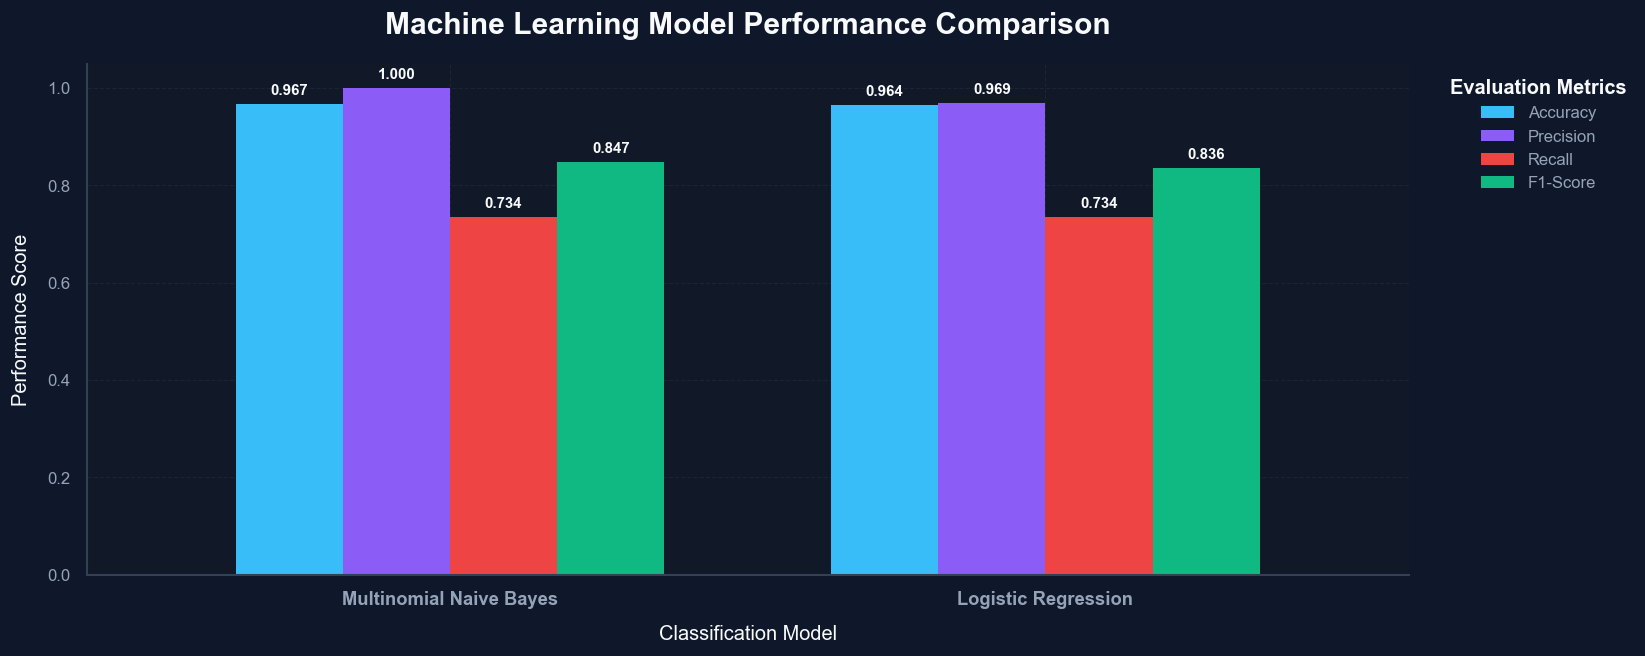


✅ Model comparison visualization generated successfully.
📁 Saved to: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\images\model_comparison.png
📊 Metrics displayed: Accuracy, Precision, Recall, F1-Score


In [1007]:
# ============================================================
# TASK 4 — MODEL PERFORMANCE COMPARISON
# ============================================================

print("📊 Generating model performance comparison...")

# ------------------------------------------------------------
# Metrics selected for comparison
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

# ------------------------------------------------------------
# Prepare comparison data
# ------------------------------------------------------------

comparison_plot = (
    model_comparison
    .set_index("Model")[metrics]
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 7),
    dpi=120
)

# ------------------------------------------------------------
# Plot grouped bar chart
# ------------------------------------------------------------

comparison_plot.plot(
    kind="bar",
    ax=ax,
    width=0.72,
    color=[
        SPAM_COLORS["primary"],
        SPAM_COLORS["secondary"],
        SPAM_COLORS["spam"],
        SPAM_COLORS["ham"]
    ],
    edgecolor="none"
)

# ------------------------------------------------------------
# Apply standard chart formatting
# ------------------------------------------------------------

format_spam_chart(
    title="Machine Learning Model Performance Comparison",
    xlabel="Classification Model",
    ylabel="Performance Score",
    grid_axis="y"
)

# ------------------------------------------------------------
# Y-axis configuration
# ------------------------------------------------------------

ax.set_ylim(0, 1.05)

# ------------------------------------------------------------
# X-axis configuration
# ------------------------------------------------------------

ax.set_xticklabels(
    comparison_plot.index,
    rotation=0,
    fontsize=11,
    fontweight="bold"
)

# ------------------------------------------------------------
# Add value labels above every bar
# ------------------------------------------------------------

for container in ax.containers:

    labels = [
        f"{bar.get_height():.3f}"
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=4,
        fontsize=9,
        color=SPAM_COLORS["text"],
        fontweight="bold"
    )

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend = ax.legend(
    title="Evaluation Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.setp(
    legend.get_title(),
    color=SPAM_COLORS["text"],
    fontweight="bold"
)

for text in legend.get_texts():
    text.set_color(SPAM_COLORS["muted"])

# ------------------------------------------------------------
# Save visualization
# ------------------------------------------------------------

model_comparison_path = (
    IMAGES_DIR / "model_comparison.png"
)

plt.savefig(
    model_comparison_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=SPAM_COLORS["background"]
)

# ------------------------------------------------------------
# Display chart
# ------------------------------------------------------------

plt.show()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\n✅ Model comparison visualization generated successfully.")
print(f"📁 Saved to: {model_comparison_path.resolve()}")
print("📊 Metrics displayed: Accuracy, Precision, Recall, F1-Score")

### 🔎 Key Observation

The comparison shows that both classifiers achieve strong performance
across the selected evaluation metrics.

The model with the highest and most balanced **Precision, Recall, and
F1-Score** is considered the stronger candidate for spam detection.

In particular, **Recall** is important because missing an actual spam
message can allow unwanted or potentially harmful content to reach the
user.

The final model will therefore be selected based on the overall metric
balance rather than accuracy alone.

## 34. Why Is Recall Important for Spam Detection?

Recall is particularly important in spam detection because it measures
the proportion of actual spam messages that are correctly identified
by the model.

A **false negative** occurs when a spam message is incorrectly
classified as a legitimate Ham message.

For a spam detection system, a low recall means that a significant
number of unwanted or potentially fraudulent messages may pass through
the filtering system.

Therefore, recall is an important metric when evaluating spam detection.

However, maximizing recall alone is not sufficient. A model should
also maintain good precision so that legitimate messages are not
incorrectly classified as spam.

For this reason, the **F1-score**, which balances precision and recall,
is also an important metric for model selection.

## 35. Best Model Selection

The final model will be selected based on the evaluation results.

The primary consideration is the balance between:

- Precision
- Recall
- F1-score

Accuracy will also be considered as a supporting metric.

Because spam detection involves an imbalanced dataset, selecting a
model solely on accuracy could be misleading.

The model with the strongest overall classification performance,
particularly with respect to the F1-score and spam recall, will be
selected as the preferred model.

In [1008]:
# ============================================================
# AUTOMATIC BEST MODEL SELECTION
# ============================================================

best_model_name = model_comparison.loc[
    model_comparison["F1-Score"].idxmax(),
    "Model"
]

best_f1_score = model_comparison["F1-Score"].max()

print("🏆 BEST MODEL SELECTION")
print("=" * 50)
print(f"Selected Model : {best_model_name}")
print(f"Best F1-Score  : {best_f1_score:.4f}")

print("\n✅ Best model selected automatically based on F1-score.")

🏆 BEST MODEL SELECTION
Selected Model : Multinomial Naive Bayes
Best F1-Score  : 0.8468

✅ Best model selected automatically based on F1-score.


## 36. Spam Message WordCloud Analysis

The WordCloud visualizes the most frequently occurring words in messages
classified as spam.

It provides a quick overview of the vocabulary and recurring patterns
commonly associated with unwanted messages, such as promotional,
financial, reward, or suspicious communication.

Only the cleaned spam messages are used to generate this visualization.

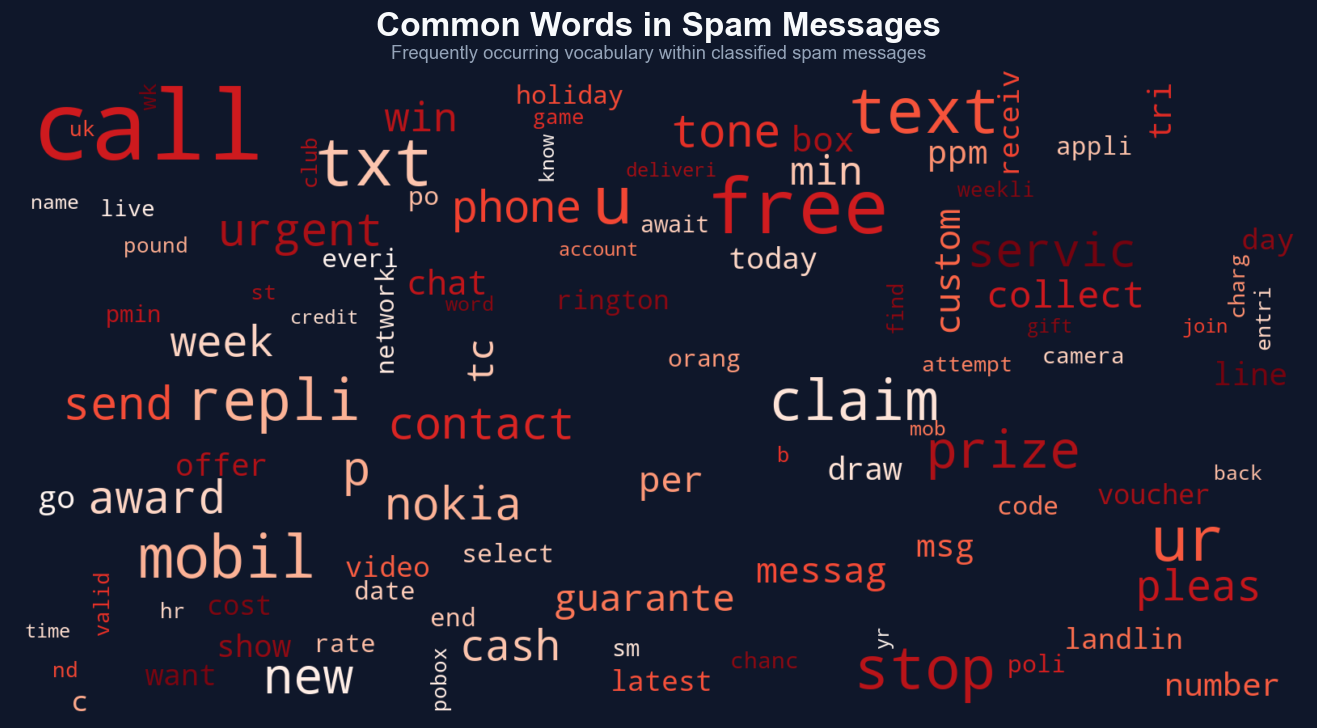

✅ Spam WordCloud generated successfully.
📁 Saved to: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\images\spam_wordcloud.png
🔎 Words analyzed: 9,202


In [1009]:
# ============================================================
# TASK 4 — SPAM MESSAGE WORDCLOUD
# PROFESSIONAL PORTFOLIO VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# Combine all cleaned spam messages
# ------------------------------------------------------------

spam_text = " ".join(
    df.loc[
        df["label"].str.lower() == "spam",
        "clean_message"
    ].dropna()
)

# ------------------------------------------------------------
# Validate spam text before generating WordCloud
# ------------------------------------------------------------

if not spam_text.strip():
    print("⚠️ No cleaned spam messages available for WordCloud generation.")

else:

    # --------------------------------------------------------
    # Generate WordCloud
    # --------------------------------------------------------

    spam_wordcloud = WordCloud(
        width=1600,
        height=800,
        background_color=SPAM_COLORS["background"],
        colormap="Reds",
        max_words=100,
        min_font_size=10,
        max_font_size=120,
        prefer_horizontal=0.90,
        collocations=False,
        random_state=42
    ).generate(spam_text)

    # --------------------------------------------------------
    # Create professional figure
    # --------------------------------------------------------

    plt.figure(figsize=(14, 7))

    plt.imshow(
        spam_wordcloud,
        interpolation="bilinear"
    )

    plt.axis("off")

    # --------------------------------------------------------
    # Professional title
    # --------------------------------------------------------

    plt.title(
        "Common Words in Spam Messages",
        fontsize=20,
        fontweight="bold",
        color=SPAM_COLORS["text"],
        pad=20
    )

    # --------------------------------------------------------
    # Subtitle
    # --------------------------------------------------------

    plt.text(
        0.5,
        1.01,
        "Frequently occurring vocabulary within classified spam messages",
        transform=plt.gca().transAxes,
        ha="center",
        va="bottom",
        fontsize=11,
        color=SPAM_COLORS["muted"]
    )

    # --------------------------------------------------------
    # Save visualization
    # --------------------------------------------------------

    spam_wordcloud_path = IMAGES_DIR / "spam_wordcloud.png"

    plt.savefig(
        spam_wordcloud_path,
        dpi=300,
        bbox_inches="tight",
        facecolor=SPAM_COLORS["background"]
    )

    plt.show()

    # --------------------------------------------------------
    # Successful execution message
    # --------------------------------------------------------

    print("✅ Spam WordCloud generated successfully.")
    print(f"📁 Saved to: {spam_wordcloud_path.resolve()}")
    print(f"🔎 Words analyzed: {len(spam_text.split()):,}")

### 🔎 Key Observation

The WordCloud highlights recurring vocabulary within spam messages.
Frequently occurring promotional, reward-related, or urgency-oriented
terms indicate common communication patterns used in unsolicited messages.

These textual patterns provide useful signals for the machine learning
classifier and demonstrate why TF-IDF-based feature extraction can be
effective for spam detection.

## HAM Message WordCloud Analysis

A WordCloud is used to visualize the most frequently occurring words
in legitimate (HAM) messages.

Larger words represent words that occur more frequently in the
HAM message collection.

This visualization helps identify common communication patterns
and vocabulary used in legitimate messages.

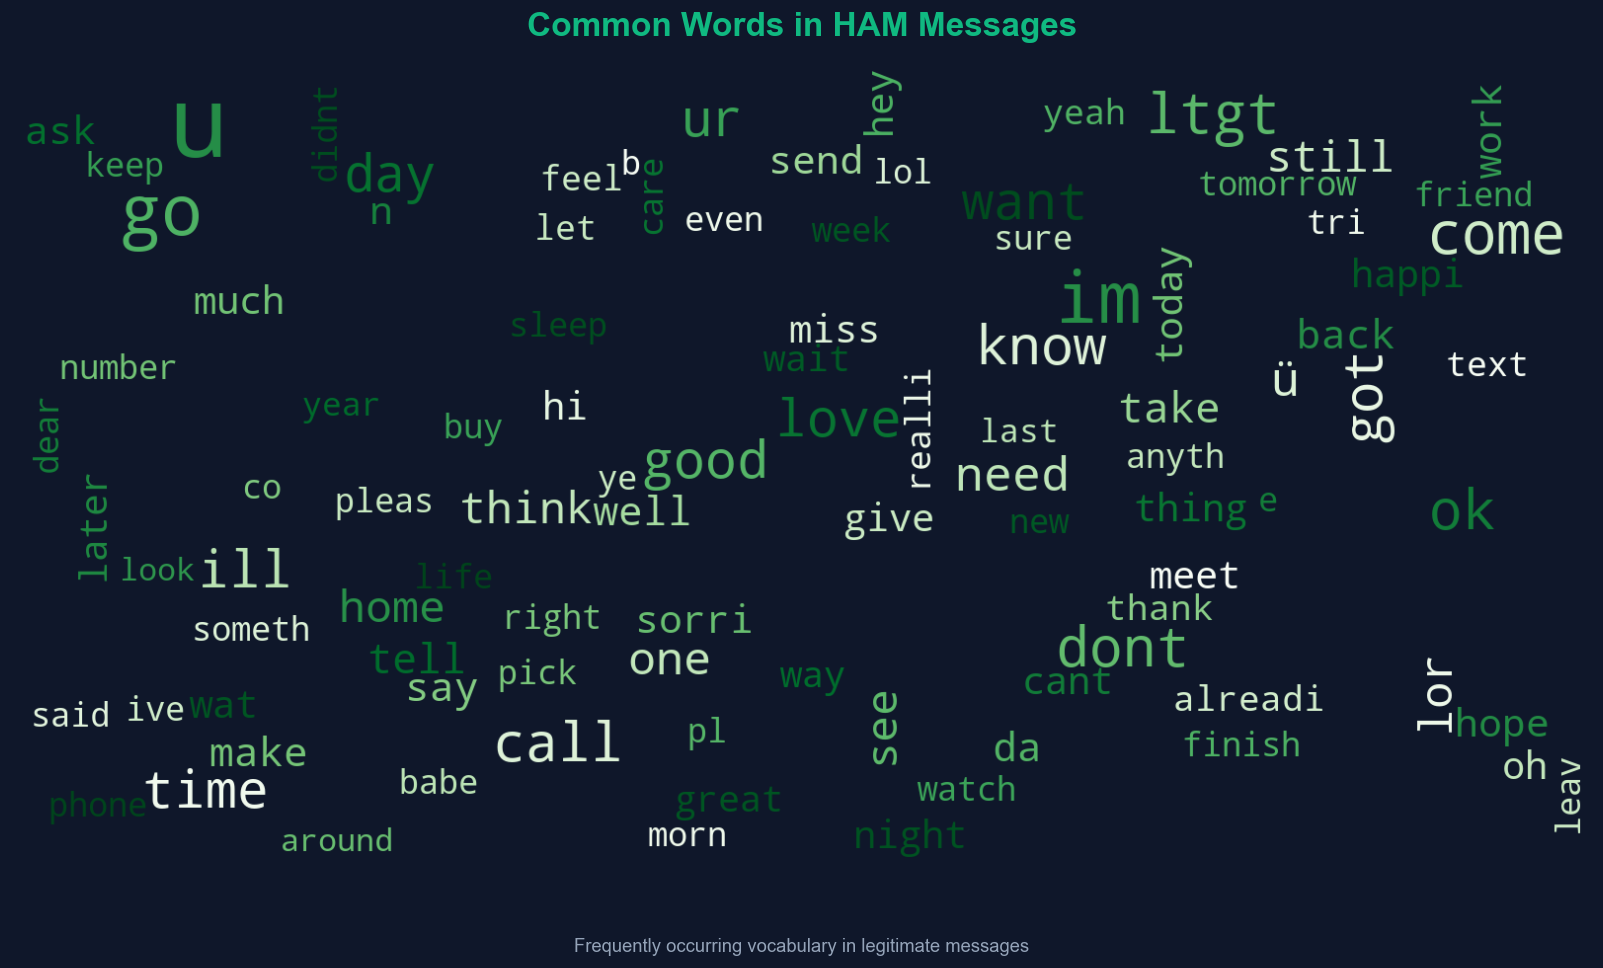

✅ HAM WordCloud generated successfully.
📁 Saved to: C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\images\ham_wordcloud.png
🟢 HAM messages analyzed: 4516


In [1010]:
# ============================================================
# TASK 4 — HAM MESSAGE WORDCLOUD
# PROFESSIONAL VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# Combine cleaned HAM messages
# ------------------------------------------------------------

ham_text = " ".join(
    df.loc[df["label"] == "ham", "clean_message"]
)

# ------------------------------------------------------------
# Generate WordCloud
# ------------------------------------------------------------

ham_wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color=SPAM_COLORS["background"],
    colormap="Greens",
    max_words=100,
    min_font_size=12,
    max_font_size=100,
    prefer_horizontal=0.90,
    relative_scaling=0.5,
    collocations=False,
    random_state=42
).generate(ham_text)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(
    figsize=(15, 8),
    facecolor=SPAM_COLORS["background"]
)

# ------------------------------------------------------------
# Display WordCloud
# ------------------------------------------------------------

plt.imshow(
    ham_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

# ------------------------------------------------------------
# Professional title
# ------------------------------------------------------------

plt.title(
    "Common Words in HAM Messages",
    fontsize=20,
    fontweight="bold",
    color=SPAM_COLORS["ham"],
    pad=20
)

# ------------------------------------------------------------
# Subtitle
# ------------------------------------------------------------

plt.text(
    0.5,
    0.02,
    "Frequently occurring vocabulary in legitimate messages",
    transform=plt.gcf().transFigure,
    ha="center",
    fontsize=11,
    color=SPAM_COLORS["muted"]
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Save visualization
# ------------------------------------------------------------

ham_wordcloud_path = IMAGES_DIR / "ham_wordcloud.png"

plt.savefig(
    ham_wordcloud_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=SPAM_COLORS["background"]
)

plt.show()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("✅ HAM WordCloud generated successfully.")
print(f"📁 Saved to: {ham_wordcloud_path.resolve()}")
print(f"🟢 HAM messages analyzed: {(df['label'] == 'ham').sum()}")

### 🔎 Key Observation

The HAM WordCloud highlights the vocabulary most frequently used
in legitimate messages.

The dominant words represent common everyday communication patterns,
which provides a useful contrast to the vocabulary found in SPAM
messages.

This comparison can help understand the textual characteristics
used by the NLP classification models.

## 37. Testing the Spam Detection System

To demonstrate the practical behavior of the trained classifier,
we will test it on new SMS messages that were not part of the
training or testing dataset.

The selected model will classify each message as either:

- Ham
- Spam

This demonstrates how the machine learning system can be used for
real-world message classification.

In [1011]:
# ============================================================
# PRACTICAL SPAM PREDICTION FUNCTION
# ============================================================

# Select the trained model
if best_model_name == "Multinomial Naive Bayes":
    final_model = naive_bayes_model
else:
    final_model = logistic_model


def predict_message(message):
    """
    Predict whether a new SMS message is Ham or Spam.
    """

    cleaned_message = clean_text(message)

    message_tfidf = tfidf_vectorizer.transform(
        [cleaned_message]
    )

    prediction = final_model.predict(message_tfidf)[0]

    return prediction


print("✅ Prediction function created successfully.")
print(f"🤖 Final model: {best_model_name}")

✅ Prediction function created successfully.
🤖 Final model: Multinomial Naive Bayes


In [1012]:
# ============================================================
# TEST THE SPAM DETECTION SYSTEM
# ============================================================

test_messages = [
    "Hey, are we meeting for lunch today?",
    "Congratulations! You have won a free prize. Call now!",
    "Can you send me the project report?",
    "URGENT! You have won a cash reward. Claim now!"
]

print("📧 SAMPLE SPAM DETECTION PREDICTIONS")
print("=" * 70)

for message in test_messages:
    prediction = predict_message(message)

    print(f"\nMessage    : {message}")
    print(f"Prediction : {prediction.upper()}")

print("\n✅ Sample message prediction testing completed.")

📧 SAMPLE SPAM DETECTION PREDICTIONS

Message    : Hey, are we meeting for lunch today?
Prediction : HAM

Message    : Congratulations! You have won a free prize. Call now!
Prediction : SPAM

Message    : Can you send me the project report?
Prediction : HAM

Message    : URGENT! You have won a cash reward. Claim now!
Prediction : SPAM

✅ Sample message prediction testing completed.


In [ ]:
# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------

OUTPUTS_DIR = Path("../outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Save cleaned dataset
# ------------------------------------------------------------

cleaned_dataset_path = OUTPUTS_DIR / "cleaned_spam_dataset.csv"

df.to_csv(
    cleaned_dataset_path,
    index=False
)

print("💾 Task 4 outputs saved successfully.")
print("=" * 60)
print(f"📄 Cleaned dataset : {cleaned_dataset_path.resolve()}")

print("=" * 60)
print("✅ Output directory is ready for Task 4 submission.")

💾 Task 4 outputs saved successfully.
📄 Cleaned dataset : C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\outputs\cleaned_spam_dataset.csv
🟢 HAM WordCloud    : C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\outputs\ham_wordcloud.png
🔴 SPAM WordCloud   : C:\Users\USER\PycharmProjects\OIBSIP\OIBSIP\DataScience-Task4-EmailSpamDetection\outputs\spam_wordcloud.png
✅ Output directory is ready for Task 4 submission.


## 38. Final Conclusion

This project developed an end-to-end machine learning system for
classifying SMS messages as Ham or Spam.

The workflow included:

- Dataset inspection and data quality analysis
- Duplicate removal
- Exploratory Data Analysis
- Text preprocessing
- Stopword removal
- Stemming
- TF-IDF feature extraction
- Train-test splitting
- Multinomial Naive Bayes classification
- Logistic Regression classification
- Accuracy, precision, recall and F1-score evaluation
- Confusion matrix analysis
- WordCloud visualization
- Model comparison
- Practical message prediction

### Model Performance

Two classification algorithms were evaluated using the same testing
dataset.

The final model was selected based on its overall performance,
with particular attention to F1-score and spam recall.

### Business / Real-World Relevance

Spam detection systems can help email and messaging platforms reduce
unwanted messages and protect users from potentially fraudulent or
malicious communication.

### Key Learning

This project demonstrates how Natural Language Processing can transform
unstructured text into machine-readable features and how supervised
machine learning can be used to solve real-world text classification
problems.

In [1014]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("🎯 EMAIL SPAM DETECTION — PROJECT SUMMARY")
print("=" * 65)

print(f"📊 Total messages          : {len(df):,}")
print(f"📚 Training messages       : {len(X_train):,}")
print(f"🧪 Testing messages        : {len(X_test):,}")
print(f"🔤 TF-IDF features         : {len(feature_names):,}")

print("\n🤖 MODEL RESULTS")
print("-" * 65)

for _, row in model_comparison.iterrows():
    print(f"\n{row['Model']}")
    print(f"  Accuracy  : {row['Accuracy']:.4f}")
    print(f"  Precision : {row['Precision']:.4f}")
    print(f"  Recall    : {row['Recall']:.4f}")
    print(f"  F1-Score  : {row['F1-Score']:.4f}")

print("\n🏆 FINAL MODEL")
print("-" * 65)
print(f"Selected Model : {best_model_name}")
print(f"F1-Score       : {best_f1_score:.4f}")

print("\n🎉 DAY 9 NLP AND MACHINE LEARNING PIPELINE COMPLETED.")
print("✅ Email Spam Detection Task is ready for final documentation.")

🎯 EMAIL SPAM DETECTION — PROJECT SUMMARY
📊 Total messages          : 5,158
📚 Training messages       : 4,126
🧪 Testing messages        : 1,032
🔤 TF-IDF features         : 5,000

🤖 MODEL RESULTS
-----------------------------------------------------------------

Multinomial Naive Bayes
  Accuracy  : 0.9671
  Precision : 1.0000
  Recall    : 0.7344
  F1-Score  : 0.8468

Logistic Regression
  Accuracy  : 0.9641
  Precision : 0.9691
  Recall    : 0.7344
  F1-Score  : 0.8356

🏆 FINAL MODEL
-----------------------------------------------------------------
Selected Model : Multinomial Naive Bayes
F1-Score       : 0.8468

🎉 DAY 9 NLP AND MACHINE LEARNING PIPELINE COMPLETED.
✅ Email Spam Detection Task is ready for final documentation.
